<a href="https://colab.research.google.com/github/kanchan874/Machine_vision/blob/main/CM23004_PR3_MV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mv3.jpg to mv3.jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
reference = cv2.imread("mv3.jpg", 0)   # Reference road sign

In [ ]:
orb = cv2.ORB_create(nfeatures=500)

kp1, des1 = orb.detectAndCompute(reference, None)
kp2, des2 = orb.detectAndCompute(test, None)

print("Reference Keypoints:", len(kp1))
print("Test Keypoints:", len(kp2))

Reference Keypoints: 500
Test Keypoints: 0


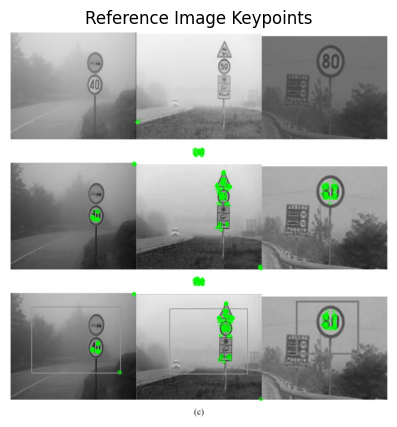

In [ ]:
img1 = cv2.drawKeypoints(reference, kp1, None, color=(0,255,0))
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img1, cmap='gray')
plt.title("Reference Image Keypoints")
plt.axis("off")

plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt

reference = cv2.imread("stop.jpg", 0)

orb = cv2.ORB_create(nfeatures=500)

kp1, des1 = orb.detectAndCompute(reference, None)

print("Number of Keypoints:", len(kp1))

Number of Keypoints: 0


Number of Keypoints: 500


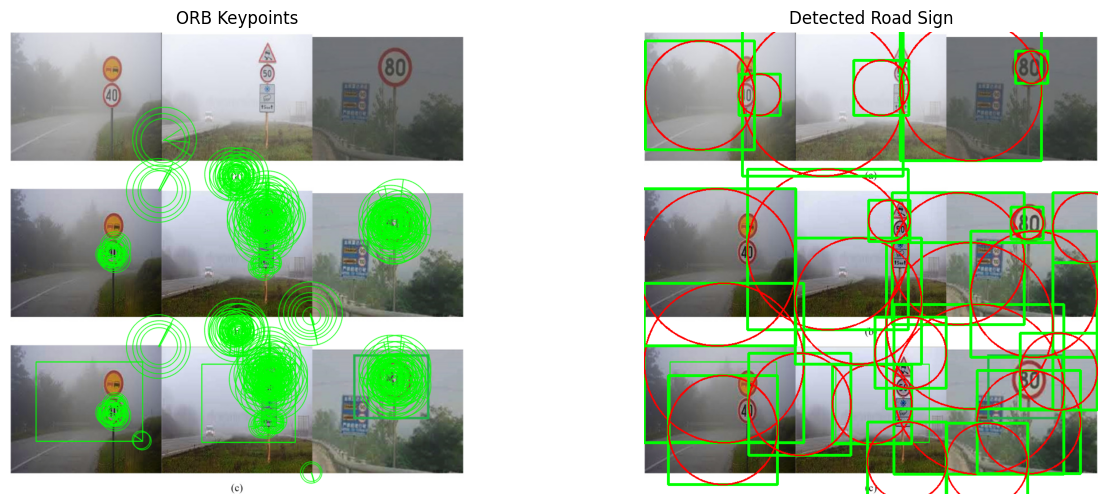

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread("mv3.jpg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create(nfeatures=500)

keypoints, descriptors = orb.detectAndCompute(gray, None)

print("Number of Keypoints:", len(keypoints))

kp_image = cv2.drawKeypoints(
    img_rgb,
    keypoints,
    None,
    color=(0,255,0),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

blur = cv2.GaussianBlur(gray,(5,5),0)

circles = cv2.HoughCircles(
    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=20,
    maxRadius=150
)

output = img_rgb.copy()

if circles is not None:
    circles = np.round(circles[0,:]).astype("int")

    for (x,y,r) in circles:

        cv2.rectangle(output,
                      (x-r,y-r),
                      (x+r,y+r),
                      (0,255,0),
                      3)

        cv2.circle(output,
                   (x,y),
                   r,
                   (255,0,0),
                   2)

plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.imshow(kp_image)
plt.title("ORB Keypoints")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(output)
plt.title("Detected Road Sign")
plt.axis("off")

plt.show()